# Transmission Spectrum Basics

Transmission spectroscopy asks a geometric question: as starlight passes through the limb of the atmosphere, how much effective area does the planet block at each wavelength?

This notebook keeps the physics intentionally minimal by using molecular absorption only. That is useful because it lets you learn the core TauREx workflow first and then notice, in later notebooks, exactly what extra processes change.

In [1]:
from _shared import build_transmission_model

context = build_transmission_model(download=False)
tm = context['tm']

print('Transmission model contributions:', [c.name for c in tm.contribution_list])

Transmission model contributions: ['Absorption']


A good habit here is to inspect the list of contributions before running the model. It makes the spectrum easier to interpret because you know which pieces of physics are allowed to shape it.

Running `model()` returns more than just the spectrum. TauREx also gives back the internal optical-depth array, which is useful when you want to understand where the spectral structure is coming from. For now, we keep that array around but focus on the spectrum itself.

In [2]:
wngrid, rprs, tau, _ = tm.model()
wlgrid = 10000 / wngrid[::-1]
rprs = rprs[::-1]

print(f'Computed {len(wngrid)} spectral points.')
print(f'Optical-depth array shape: {tau.shape}')

Computed 76744 spectral points.
Optical-depth array shape: (100, 76744)


In [3]:
print(f'Transit-depth range: {rprs.min():.6e} to {rprs.max():.6e}')
print(f'Wavelength range: {wlgrid.min():.3f} to {wlgrid.max():.3f} um')

Transit-depth range: 1.494561e-02 to 2.072073e-02
Wavelength range: 0.300 to 50.002 um


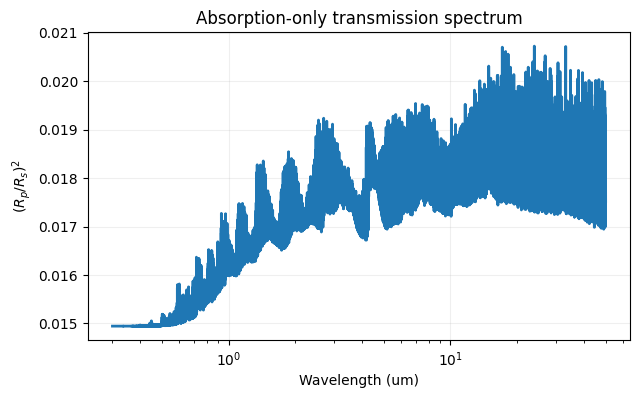

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(wlgrid, rprs, lw=2)
plt.xscale('log')
plt.xlabel('Wavelength (um)')
plt.ylabel('$(R_p/R_s)^2$')
plt.title('Absorption-only transmission spectrum')
plt.grid(alpha=0.2)

In [5]:
peak_index = rprs.argmax()
print(f'Largest feature near {wlgrid[peak_index]:.3f} um with depth {rprs[peak_index]:.6e}')

Largest feature near 23.860 um with depth 2.072073e-02


One of the simplest questions you can ask of this figure is: where is the atmosphere more opaque? In transmission, larger values of $(R_p/R_s)^2$ usually mean the atmosphere becomes opaque higher up, making the planet look effectively larger.

When you inspect this plot, focus on the broad pattern rather than individual line positions. At this stage the important lesson is that TauREx turns a set of atmospheric components plus radiative contributions into a wavelength-dependent transit depth. Later notebooks add extra physics and compare how the shape changes.